In [ ]:
# !pip uninstall torch torchvision torchaudio -y

In [ ]:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

In [46]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
import torchvision.models as models
import json
import random
from tqdm import tqdm
from torch.nn import BCEWithLogitsLoss, Module, Linear, ReLU
from utils import *


In [ ]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Number of GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Current GPU:", torch.cuda.get_device_name(0))

In [ ]:
print(torch.cuda.is_available())

In [ ]:
LEN = 16000
class SimCLRDataset(Dataset):
    def __init__(self):
        self.image_dir = os.path.join(os.getcwd(), 'dataset')
        self.images = [f for f in os.listdir(self.image_dir) 
                      if os.path.isfile(os.path.join(self.image_dir, f))]

        self.simclr_transform = T.Compose([
            T.RandomResizedCrop(40),
            T.RandomHorizontalFlip(),
            T.RandomApply([T.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
            T.RandomGrayscale(p=0.2),
            T.GaussianBlur(kernel_size=3),
            T.ToTensor(),
            T.Normalize((0.5,), (0.5,)) 
        ])

    def __getitem__(self, index):
        image_path = os.path.join(self.image_dir, self.images[index])
        image = Image.open(image_path).convert('L')
        
        crop1 = random.randint(0, LEN-45)
        crop2 = random.randint(0, LEN-45)
        image1 = image.crop((crop1, 0, crop1+40, 40))
        image2 = image.crop((crop2, 0, crop2+40, 40))
        
        xi = self.simclr_transform(image1)
        xj = self.simclr_transform(image2)
        return xi, xj

    def __len__(self):
        return len(self.images)
    
# dataset = SimCLRDataset(simclr_transform)
# sample = dataset[0] 
# print(sample[0].shape, sample[1].shape)

# Модели

In [24]:
class SimCLRModel(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()
        base_model = models.resnet18(weights=None) # ResNet без последнего FC слоя
        base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        num_ftrs = base_model.fc.in_features
        base_model.fc = nn.Identity()  
        self.encoder = base_model
        self.projection_head = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projection_head(h)
        return z

In [ ]:
class SubCharCNNEncoder(nn.Module):
    def __init__(self):
        super(SubCharCNNEncoder, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=30, stride=1, padding=14)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=30, stride=1, padding=14)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 9 * 9, 64)   
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return x

In [ ]:
class SimCLRModelCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        base_model = SubCharCNNEncoder()
        
        checkpoint = torch.load('exp dataset_vrbl sub_char_cnn_cnn.pt', map_location='cpu')
        
        model_dict = base_model.state_dict()
        pretrained_dict = {k: v for k, v in checkpoint.items() if k in model_dict}
        model_dict.update(pretrained_dict)
        base_model.load_state_dict(model_dict)
        
        self.encoder = base_model
        
        self.projection_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 8)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projection_head(h)
        return z

# Функция потерь

In [2]:
def nt_xent_loss(z_i, z_j, temperature=0.5):
    z = torch.cat([z_i, z_j], dim=0) # Объединяем все представления в одну матрицу (удваиваем размер батча)
    z = F.normalize(z, dim=1) # L2-нормализация по вектору признаков

    similarity = torch.matmul(z, z.T) # [2*N, 2*N] матрица косинусных сходств
    N = z_i.shape[0] # исходный размер батча

    mask = (~torch.eye(2*N, dtype=bool)).to(z.device) # False на диагонали 
    sim = similarity / temperature
    exp_sim = torch.exp(sim) * mask # Обнуляем диагональ, чтобы не учитывать сходство вектора с самим собой

    positive_sim = torch.exp(F.cosine_similarity(z_i, z_j) / temperature)
    positives = torch.cat([positive_sim, positive_sim], dim=0) # позитивные пары (дублируем, так как каждая аугментация должна притягиваться к своей паре)

    denominator = exp_sim.sum(dim=1) # сумма по всем примерам
    loss = -torch.log(positives / denominator)
    return loss.mean() # Loss как Softmax: максимизировать схожесть положительных пар относительно всех остальных

# Обучение

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

contrastive_dataset = SimCLRDataset()
train_loader = DataLoader(contrastive_dataset, batch_size=128, shuffle=True)

model = SimCLRModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

for epoch in range(30):
    model.train()
    total_loss = 0
    for x_i, x_j in tqdm(train_loader):
        x_i, x_j = x_i.to(device), x_j.to(device)
        z_i = model(x_i)
        z_j = model(x_j)

        loss = nt_xent_loss(z_i, z_j)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss / len(train_loader):.4f}")

NameError: name 'SimCLRDataset' is not defined

In [ ]:
torch.save(model.state_dict(), 'contrastive_model.pt')

# Тестирование

## Модель

In [18]:
class ModelClassifier(nn.Module):
    def __init__(self, output_dim=120):
        super().__init__()
        self.fc1 = nn.Linear(128, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [19]:
class FontCropDataset(Dataset):
    def __init__(self, image_dir, split='train', crop_size=40, step=40, length=16000):

        self.image_dir = image_dir
        self.images = os.listdir(image_dir)
        self.split = split
        self.crop_size = crop_size
        self.step = step
        self.length = length

        if split == 'train':
            self.transform = T.Compose([
                T.RandomHorizontalFlip(),
                T.RandomGrayscale(p=0.2),
                T.GaussianBlur(kernel_size=3),
                T.ToTensor(),
                T.Normalize((0.5,), (0.5,))
            ])
        else:
            self.transform = T.Compose([
                T.ToTensor(),
                T.Normalize((0.5,), (0.5,))
            ])

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.images[idx])
        image = Image.open(image_path).convert('L')
        mid = self.length // 2

        crops = []

        if self.split == 'train':
            for start in range(0, mid - self.crop_size + 1, self.step):
                crop = image.crop((start, 0, start + self.crop_size, self.crop_size))
                crops.append(self.transform(crop))
        else:
            for start in range(mid, self.length - self.crop_size + 1, self.step):
                crop = image.crop((start, 0, start + self.crop_size, self.crop_size))
                crops.append(self.transform(crop))

        return crops, os.path.basename(image_path)

    def __len__(self):
        return len(self.images)

In [50]:
def get_font_vector(encoder, classifier, crop_tensor, device):

    encoder.eval()
    classifier.eval()
    crop_tensor = crop_tensor.to(device)

    with torch.no_grad():
        feats = encoder(crop_tensor)
        logits = classifier(feats)
        vector_pred = torch.sigmoid(logits.squeeze(0))

    return vector_pred.cpu().numpy()


In [21]:
def train_classifier(encoder, classifier, dataloader, device, panose_vectors,
                                 num_epochs=10, log_file="log.train.txt"):
    encoder.eval()
    classifier.train()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)

    for epoch in range(num_epochs):
        total_loss = 0

        for crops_list, name_list in tqdm(dataloader):
            for crops, name in zip(crops_list, name_list):
                font_name = os.path.splitext(name)[0]
                if font_name not in panose_vectors:
                    continue

                # Выбираем один кроп случайно
                idx = np.random.randint(len(crops))
                crop = crops[idx].unsqueeze(0).to(device)  # 1 x 1 x 40 x 40

                # Предсказанный вектор
                with torch.no_grad():
                    feats = encoder(crop)
                logits = classifier(feats)
                vector_pred = logits.squeeze(0)  # 120 элементов

                # Целевой PANOSE-вектор
                target = torch.tensor(panose_vectors[font_name], dtype=torch.float32).to(device)

                # BCE loss
                loss = criterion(vector_pred, target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
        with open(log_file, "a") as f:
            f.write(f"Epoch {epoch+1}: loss={avg_loss:.4f}\n")

In [22]:
def evaluate(encoder, classifier, test_dataset, panose_vectors, device):
    encoder.eval()
    classifier.eval()
    cosine_scores = []

    for crops_list, name in test_dataset:
        font_name = os.path.splitext(name)[0]
        if font_name not in panose_vectors:
            continue

        preds = []
        for crop in crops_list:
            crop = crop.unsqueeze(0).to(device)
            with torch.no_grad():
                feats = encoder(crop)
                logits = classifier(feats)
                preds.append(torch.sigmoid(logits).cpu().numpy())

        if not preds:
            continue

        pred_mean = np.mean(preds, axis=0)
        target = np.array(panose_vectors[font_name])

        pred_norm = pred_mean / (np.linalg.norm(pred_mean))
        target_norm = target / (np.linalg.norm(target))

        cosine = np.dot(pred_norm, target_norm)
        cosine_scores.append(cosine)

    print(f"Среднее косинусное сходствл среди всех: {np.mean(cosine_scores):.4f}")
    return np.mean(cosine_scores)

In [27]:

train_dataset = FontCropDataset("test", split="train")
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)

test_dataset = FontCropDataset("test", split="test")

encoder = SimCLRModel().to(device)
encoder.load_state_dict(torch.load("contrastive_model.pt", map_location=device))
encoder.eval()

classifier = ModelClassifier().to(device)

panose_vectors = PanoseVector.get_vector()

train_classifier(encoder, classifier, train_loader, device, panose_vectors, num_epochs=30)

evaluate(encoder, classifier, test_dataset, panose_vectors, device)


100%|██████████| 120/120 [00:12<00:00,  9.90it/s]


Epoch 1/30, Loss: 0.2421


100%|██████████| 120/120 [00:13<00:00,  9.10it/s]


Epoch 2/30, Loss: 0.1318


100%|██████████| 120/120 [00:13<00:00,  8.78it/s]


...

100%|██████████| 120/120 [00:15<00:00,  7.94it/s]


Epoch 29/30, Loss: 0.1083


100%|██████████| 120/120 [00:14<00:00,  8.03it/s]


Epoch 30/30, Loss: 0.1090
Cosine similarity (mean over fonts): 0.6531


0.6531068633650456

In [40]:
torch.save(classifier.state_dict(), 'classifier_model.pt')

Имя шрифта: ANTQUAI
Предсказанный вектор: [4.46449295e-02 9.33407500e-05 7.33717859e-01 1.02602281e-01
 1.00741672e-04 1.12970789e-04 5.70604801e-01 3.63775164e-01
 7.73227364e-02 1.39777680e-04 7.68157840e-02 3.83237489e-02
 2.02622399e-01 6.84145987e-02 1.34080910e-04 3.27823982e-02
 1.33496491e-04 7.21252654e-05 1.39541022e-04 2.93133706e-01
 8.12342187e-05 1.21252022e-04 4.39316668e-02 5.99125810e-02
 2.61708409e-01 9.36441720e-02 1.35090004e-03 2.51835674e-01
 1.40272841e-01 1.10167436e-01 2.03715533e-01 1.70566418e-04
 1.71144929e-04 1.21851495e-04 4.14987793e-03 9.77333984e-05
 1.01549678e-01 1.79185793e-02 1.13910154e-01 4.13296111e-02
 2.23375559e-01 2.84917802e-01 8.44232887e-02 7.98181538e-03
 1.16918331e-04 9.47366643e-05 1.30864981e-04 9.09407511e-02
 3.41006927e-02 1.96655944e-01 1.47994235e-01 3.71692777e-02
 1.65352772e-04 1.48783473e-03 1.59736825e-04 1.45739672e-04
 1.32063180e-01 1.20896980e-01 9.88776982e-03 1.14877592e-04
 9.97073075e-05 1.75541427e-04 1.42462959e-

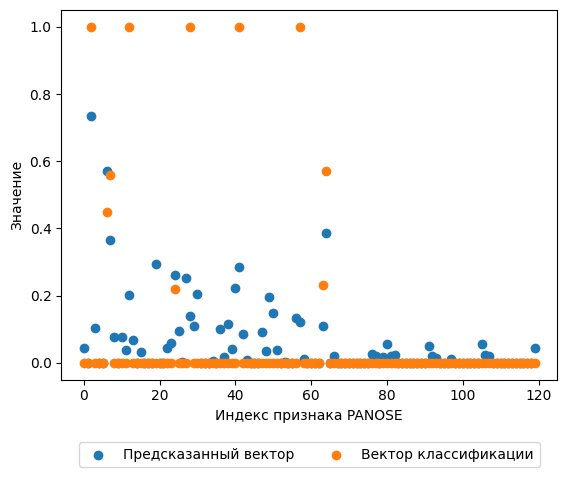

In [39]:
crops_list, name = test_dataset[3]

crop = random.choice(crops_list).unsqueeze(0).to(device)

vector_pred = get_font_vector(encoder, classifier, crop, device)

font_name = os.path.splitext(name)[0]
vector_target = np.array(panose_vectors[font_name])

print(f"Имя шрифта: {font_name}")
print("Предсказанный вектор:", vector_pred)
print("Реальный вектор:", vector_target)


vector_pred_np = np.array(vector_pred)
vector_target_np = np.array(vector_target)

x = np.arange(len(vector_pred_np))

plt.figure()
plt.scatter(x, vector_pred_np, label='Предсказанный вектор')
plt.scatter(x, vector_target_np, label='Вектор классификации')
plt.xlabel('Индекс признака PANOSE')
plt.ylabel('Значение')
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.show()



# Нахождение 10 схожих векторов

In [16]:
import json
import numpy as np

panose_vectors = PanoseVector.get_vector()

def to_list(vec):
    if isinstance(vec, np.ndarray):
        return vec.tolist()
    return list(vec)

data = {
    font: to_list(vec)
    for font, vec in panose_vectors.items()
}

with open("panose_vectors.json", "w", encoding="utf-8") as f:
    json.dump(
        data,
        f,
        ensure_ascii=False,
        indent=2,
    )


In [59]:
with open("panose_vectors.json", "r", encoding="utf-8") as f:
    panose_json = json.load(f)

namelist = list(panose_json.keys())
vectors_json = np.array(list(panose_json.values()))

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

crops_list, name = test_dataset[3]

crop = random.choice(crops_list).unsqueeze(0).to(device)

vector_pred = get_font_vector(
    encoder, classifier, crop, device
)

vec = np.array(vector_pred)

Coslist = [
    cosine_similarity(vec, vec_from_json)
    for vec_from_json in vectors_json
]

Coslist = np.array(Coslist)

Ind = np.argsort(Coslist)[::-1]

print("Топ-10 наиболее похожих шрифтов:")
for i in Ind[:10]:
    print(f"{namelist[i]}  |  cos = {Coslist[i]:.4f}")


Топ-10 наиболее похожих шрифтов:
ANTQUAB  |  cos = 0.8192
BKANT  |  cos = 0.8123
ANTQUABI  |  cos = 0.7891
ANTQUAI  |  cos = 0.7715
georgiab  |  cos = 0.7252
CENTURY  |  cos = 0.7229
georgiaz  |  cos = 0.7048
georgia  |  cos = 0.7017
timesbd  |  cos = 0.6978
Candarab  |  cos = 0.6887
